# Hackathon:
2026 Winter 最後修改日期：2025/12/17
# Dataset reference
Chest X-rays: [Atelectasis](https://stanfordmlgroup.github.io/competitions/chexpert/) \\

[較大的資料集](https://drive.google.com/drive/folders/1xikeb-1ghl8WryS7bwAchrn036i4n-qh?usp=sharing)

## 0\. 準備工作

* 請先至左上角的「檔案」內點選「在雲端硬碟中儲存複本」。


## 1\. 安裝，載入套件

In [ ]:
!pip install -U gdown monai timm timm_vis

In [ ]:
#   ,
#__/ \__
#\     /
#/_   _\
#  \ /
#   '
import logging
import math
import os
import shutil
import yaml
import tarfile
from datetime import datetime
from tqdm.notebook import tqdm

import gdown
import monai
import numpy as np
import timm
import torch
from matplotlib import pyplot as plt
from monai.bundle import ConfigParser
from monai.data import CacheDataset, DataLoader, Dataset
from monai.transforms import (
    Compose, EnsureTyped, LoadImaged,
    MaskIntensityd, Orientationd, RandAffined, RandFlipd, RandGaussianNoiseD,
    RepeatChanneld, Resized, ScaleIntensityd,
    ScaleIntensityRanged, ToDeviced, Transform,
)
from monai.utils.misc import set_determinism
from PIL import Image
from sklearn.metrics import auc, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
from torch.nn import Module
from torch.nn.modules.loss import _Loss
from torch.optim import Optimizer
from torchvision import transforms

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


## 2\. 設定參數

In [ ]:
disease_list = [
    'Atelectasis', 'Cardiomegaly',
    'Colon_Polyp', 'Diabetic_Retinopathy',
    'Melanoma'
]

In [ ]:
# Status Update Variables
environ_chgnd = False
data_chgnd = False
training_chgnd = False

In [ ]:
#   ,
#__/ \__
#\     /
#/_   _\
#  \ /
#   '
group_num = 8 #@param {type:"slider", min: 1, max: 15}
data_name = disease_list[(group_num-1)%5]

args = {
    "environ": {
        ############### Environment parameters #################
        # Set seed for reproducibility
        "config_file": "config.yaml",
        "seed": 42,
        "data_name": data_name,
        ############### Environment parameters ################# // populate_data_lists for seed // unzip_data, load_data_list, get_data_count for data_name
    },

    "data": {
      ############### Data parameters #################
      #>>>>>>>>>>>>Am I correct?<<<<<<<<<<<<<<<<<<<<<<#
      # number of data for train, validation, test // populate_data_lists
      "train_percentage": 0.23,
      "val_percentage": 25,
      "test_percentage": 25,
      ############### Data parameters #################

      ############### Transform, Augmentation parameters #################
      #>>>>>>>>>>>>Am I too high?<<<<<<<<<<<<<<<<<<<<<<#
      "spatial_size": [10000, 10000],
      #>>>>>>>>>>>>Am I correct?<<<<<<<<<<<<<<<<<<<<<<<#
      "repeats": 2,

      #>>>>>>>>Are my values correct?<<<<<<<<<<<<<<<<<<#
      "rotate_range": [[np.pi/18, np.pi/9]], # in radian, e.g., [np.pi/4, np.pi/2]
      "shear_range": [[0, 0], [0, 0]], # in ratio e.g., [0, 1]
      "translate_range": [[30, 60], [1000, 2000]], # in number of pixel, e.g., [0, 128]
      "scale_range": [[0.0001, 0.0001], [0.0001, 0.0001]], # in ratio e.g., [0, 1]
      "affine_prob": 1,

      "spatial_axis": [0, 1],
      "flip_prob": 0.5,

      'a_min': -125,
      'a_max': 200,

      ######## for dataset
      "cache_rate": 1,
    },
    # number of data to be visualized
    "img_cnt": 5,
    ############### Transform, Augmentation parameters #################

    "training": {
      ############### Training parameters #################
      # Set the hyperparameters
      #>>>>>>>>>>>>Are we correct?<<<<<<<<<<<<<<<<<<<<<<#
      "num_epoch": 1,
      "batch_size": 1,
      "lr": 10,

      'timm_model': 'resnet18',
      'num_classes': 1,
      ############### Training parameters #################
    },

    ############### Inference parameters #################
    #>>>>>>>>>>>>Am I correct?<<<<<<<<<<<<<<<<<<<<<<<#
    "threshold": 1,
    ############### Inference parameters #################
}

with open(f'{datetime.strftime(datetime.now(), "%m%d_%H%M%S")}_{args["environ"]["config_file"]}', 'w') as fp:
  yaml.dump(args, fp)

configs = [a for a in os.listdir() if args["environ"]["config_file"] in a]
configs = sorted(configs, key=lambda x: datetime.strptime(x.replace(f'_{args["environ"]["config_file"]}', ""), "%m%d_%H%M%S"))

if len(configs) > 1:
  with open(configs[-1], 'r') as fp:
    args2 = yaml.safe_load(fp)

  with open(configs[-2], 'r') as fp:
    args1 = yaml.safe_load(fp)

  if args1["environ"] != args2["environ"]:
    environ_chgnd = True
  if args1["data"] != args2["data"]:
    data_chgnd = True
  if args1["training"] != args2["training"]:
    training_chgnd = True

# transforms
loaders = [
    LoadImaged(keys='image', reader='pilreader', ensure_channel_first=True),
    EnsureTyped(keys=['image', 'label'])
]

preprocess = [
    Resized(keys='image', spatial_size=args["data"]['spatial_size']),
    RepeatChanneld(keys='image', repeats=args["data"]["repeats"]),
]

augmentation = [
    RandAffined(
        keys='image',
        rotate_range=args["data"]['rotate_range'],
        shear_range=args["data"]['shear_range'],
        translate_range=args["data"]['translate_range'],
        scale_range=args["data"]['scale_range'],
        prob=args["data"]['affine_prob'],
        padding_mode='border'
    ),
    RandGaussianNoiseD(keys='image'),
]

## 3\. 環境設定

In [ ]:
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s.%(msecs)03d][%(levelname)5s](%(name)s) - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)
logger = logging.getLogger()

In [ ]:
# Set seed for reproducibility
set_determinism(args["environ"]['seed'])

## 4\. 定義函式

Only two differences: download_and_untar_data and get_data_count

In [ ]:
#   ,
#__/ \__
#\     /
#/_   _\
#  \ /
#   '
def _load_yaml(args: dict):
  configs = [a for a in os.listdir() if args["environ"]["config_file"] in a]
  configs = sorted(configs, key=lambda x: datetime.strptime(x.replace(f'_{args["environ"]["config_file"]}', ""), "%m%d_%H%M%S"))
  with open(configs[-1], 'r') as fp:
    return yaml.safe_load(fp)

In [ ]:
def download_and_untar_data(args: dict, group_num: int):
  args = _load_yaml(args)

  file_ids = [
    '1w48H3hLAXT7oxQfy1QvMpkVvzVASOFNQ', '1kvE5-nqM4Cp7UjmQaSZwhIBtIlhu_bCj',
    '15R1shEqnTF6QJbTy4QJFG6cW0LXTAjVk', '1hdH86SIDh0eO64-ArToRhdLxJ6ICXbuc',
    '1X3Fwtk4Q2rUXWbkyJvuTTo5zhxYgsdM0', '1GUKdWnZx8KR-XCy8dWIPn_q4h8vVqFYN',
    '1-EBbLErb3f8CD7lznZ4LZVqcBKn5kb6G', '17VhHyTOfxadT3EuoqOWfTDMXjM7ix3ZU',
    '1wOZHBzJtbN15qBy2bFrw4CPkmgYspsni', '105qkBolkdQdJxkl3jhUJF48ITvBFCpAP'
  ]

  tar_file = f'{args["environ"]["data_name"]}.tar.gz'
  parent_dir = '/content/'
  data_dir = f'{parent_dir}{args["environ"]["data_name"]}'

  if not os.path.exists(tar_file):
      id = file_ids[(group_num-1) % 10]
      logger.info(f"id = {id}, tar_file = {tar_file}")
      gdown.download(id=id, output=tar_file)
  else:
      logger.info("Data already downloaded!")

  # unzip the file
  if os.path.exists(f'{parent_dir}{tar_file}') and not os.path.exists(data_dir):
      logger.info('Untarring...')
      with tarfile.open(tar_file, 'r') as tar:
        tar.extractall(path=parent_dir)

  if not os.path.exists(data_dir):
      logger.info("Data directory doesn't exist.")
  else:
      logger.info("Data successfully downloaded and unzipped")


In [ ]:
def get_data_count(data_dicts: list):
  images = [a["image"] for a in data_dicts]

  # check how much data we have
  logger.info(f'Number of images: {len(images)}')

In [ ]:
def load_data_list(args: dict):
  args = _load_yaml(args)
  with open(f'/content/{args["environ"]["data_name"]}/data_list.yaml', 'r') as fp:
    data = yaml.safe_load(fp)
  return data['data']

In [ ]:
def populate_data_lists(args: dict, data_dicts: list):
  # Separate data into training, validation, and testing set
  args = _load_yaml(args)
  labels = [a["label"] for a in data_dicts]
  train_dicts, val_test_dicts = train_test_split(
      data_dicts,
      train_size=args["data"]["train_percentage"],
      test_size=args["data"]["val_percentage"]+args["data"]["test_percentage"],
      stratify=labels,
      random_state=args["environ"]["seed"],
      shuffle=True,
  )

  val_test_labels = [a["label"] for a in val_test_dicts]
  val_dicts, test_dicts = train_test_split(
      val_test_dicts,
      train_size=args["data"]["val_percentage"]/(args["data"]["val_percentage"]+args["data"]["test_percentage"]),
      test_size=args["data"]["test_percentage"]/(args["data"]["val_percentage"]+args["data"]["test_percentage"]),
      stratify=val_test_labels,
      random_state=args["environ"]["seed"],
      shuffle=True,
  )
  return train_dicts, val_dicts, test_dicts


In [ ]:
# check label distribution
def check_dist(dataset: Dataset):
    positive = 0
    negative = 0
    for data in dataset:
        if data['label'].item() == 1:
            positive += 1
        else:
            negative += 1
    logger.info(
        f'''number of positive = {positive:.0f},
        number of negative = {negative:.0f},
        number of total data = {len(dataset)}'''
    )

In [ ]:
def generate_dataset(args: dict, datalist: list, transform: Transform):
  args = _load_yaml(args)

  dataset = CacheDataset(datalist, transform, cache_rate=args["data"]['cache_rate'])
  return dataset

In [ ]:
def generate_dataloader(args: dict, dataset: Dataset, shuffle: bool = False):
  args = _load_yaml(args)
  return DataLoader(dataset, batch_size=args["training"]['batch_size'], shuffle=shuffle)

In [ ]:
#   ,
#__/ \__
#\     /
#/_   _\
#  \ /
#   '
def create_timm_model(args: dict):
  args = _load_yaml(args)
  return timm.create_model(args["training"]['timm_model'], pretrained=True, num_classes=args["training"]['num_classes'])

In [ ]:
#   ,
#__/ \__
#\     /
#/_   _\
#  \ /
#   '
def generate_optimizer(args: dict, model: Module):
  args = _load_yaml(args)
  return torch.optim.Adam(model.parameters(), lr=args["training"]['lr'])

In [ ]:
def train_one_epoch(args: dict, model: Module, criterion: _Loss, optimizer: Optimizer, train_loader: DataLoader, val_loader: DataLoader):
    args = _load_yaml(args)
    train_loss = 0.0
    val_loss = 0.0
    # training
    model.train()
    for data in train_loader:
        images = data['image'].to(device)
        labels = data['label'].to(device)

        optimizer.zero_grad() # zero out the optimizer gradient
        preds = model(images) # model prediction
        loss = criterion(preds, labels) # calculate loss
        loss.backward() # calculate gradient of loss w.r.t. model weights
        optimizer.step() # weights update
        train_loss += loss.item()

    # validation
    model.eval()
    with torch.no_grad():
        for data in val_loader:
            images = data['image'].to(device)
            labels = data['label'].to(device)

            preds = model(images)
            loss = criterion(preds, labels)
            val_loss += loss.item()


    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    return train_loss, val_loss

In [ ]:
def train(args, model, criterion, optimizer, train_loader, val_loader):
  args = _load_yaml(args)
  record = {'train': [], 'val': []}
  best_val_loss = np.inf
  for epoch in tqdm(range(args["training"]["num_epoch"])):
      train_loss, val_loss = train_one_epoch(args, model, criterion, optimizer, train_loader, val_loader)

      # save model with lowest validation loss
      if val_loss < best_val_loss:
          best_val_loss = val_loss
          torch.save(model.state_dict(), "/content/best_weights.pth")

      record['train'].append(train_loss)
      record['val'].append(val_loss)

      logger.info(
          f'''[{epoch+1}/{args["training"]["num_epoch"]}]
          Train loss: {train_loss:3.3f},
          Validation loss: {val_loss:3.3f} '''
      )
  return record

In [ ]:
#   ,
#__/ \__
#\     /
#/_   _\
#  \ /
#   '
def infer(model, data_loader, details=False):

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.eval()
    sigmoid = torch.nn.Sigmoid()
    thres = args["threshold"]

    y_true = []
    y_pred = []

    with torch.no_grad():
        for data in tqdm(data_loader):
            images = data['image'].to(device)
            labels = data['label'].to(device)

            preds = sigmoid(model(images))

            for i, (pred, label) in enumerate(zip(preds, labels)):
                y_pred.append(pred.item())
                y_true.append(label.item())

                if details:
                    binary_pred = (pred >= thres).float()
                    if (binary_pred != label):
                        print(f'{images.meta["filename_or_obj"][i]} mismatch between prediction of {binary_pred.item()} and label of {label.item()}')
                    else:
                        print(f'{images.meta["filename_or_obj"][i]} match between prediction of {binary_pred.item()} and label of {label.item()}')

    return y_true, y_pred

In [ ]:
# helper function for plotting image
def plot_samples(samples, with_mask=False):

    for data in samples:
      column_cnt = 2 if with_mask else 1
      image = data['image'][0]

      fig, axs = plt.subplots(1, column_cnt, figsize=(5*column_cnt, 4))
      image_title = f"Label: {data['label'].item()}"

      if with_mask:
          axs[0].imshow(image, cmap='gray')
          axs[0].set_title(image_title)

          label_title = "Corresponding Mask"
          mask = data['mask'][0]
          axs[1].imshow(mask, cmap='gray')
          axs[1].set_title(label_title)

      else:
          axs.imshow(image, cmap='gray')
          axs.set_title(image_title)

      plt.show()

def plot_transform_result(data, trans_data, with_mask=False, with_histogram=False):

    assert not (with_mask and with_histogram), "Cannot plot both histogram and mask"

    if with_mask or with_histogram:
        column_cnt = 4
        axis_for_trans_data = 2
    else:
        column_cnt = 2
        axis_for_trans_data = 1

    fig, axs = plt.subplots(1, column_cnt, figsize=(5*column_cnt, 4))

    axs[0].imshow(data['image'][0], cmap='gray')
    axs[0].set_title("Original Data")

    axs[axis_for_trans_data].imshow(trans_data['image'][0], cmap='gray')
    axs[axis_for_trans_data].set_title("Transformed Data")

    if with_mask:
        axs[1].imshow(data['mask'][0], cmap='gray')
        axs[1].set_title("Original Mask")
        axs[3].imshow(trans_data['mask'][0], cmap='gray')
        axs[3].set_title("Transformed Mask")

    if with_histogram:
        ori_counts, ori_bins = np.histogram(data['image'][0], bins=256)
        axs[1].hist(ori_bins[:-1], bins=256, weights=ori_counts, log=True)
        trans_counts, trans_bins = np.histogram(trans_data['image'][0], bins=256)
        axs[3].hist(trans_bins[:-1], bins=256, weights=trans_counts, log=True)

    plt.show()

In [ ]:
def plot_loss_curves(args: dict, record: dict):
  # plot loss
  args = _load_yaml(args)

  fig, axs = plt.subplots(1, 1, figsize=(10, 8))

  axs.plot(record['train'])
  axs.plot(record['val'])
  axs.set_xticks(range(0, args["training"]["num_epoch"]+1, 5))
  axs.set_ylabel('Loss')
  axs.set_xlabel('Epoch')
  axs.legend(['train', 'val'], loc='lower left')
  plt.show()

In [ ]:
def plot_roc_and_show_result(args: dict, y_true, y_pred, title=''):
    # plot the ROC curve
    args = _load_yaml(args)
    thres = args["threshold"]
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.ylabel('Sensitivity')
    plt.xlabel('1 - Specificity')
    plt.show()

    # binarize the predictions
    y_pred = np.where(np.array(y_pred)>=thres, 1, 0)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    logger.info(
        f'''True positive: {tp}\n
        False positive: {fp}\n
        False negative: {fn}\n
        True negative: {tn}\n
        Sensitivity: {sensitivity:.4f}\n
        Specificity: {specificity:.4f}\n'''
    )

In [ ]:
def update(environ_update=False, data_update=False, training_update=False):
    global environ_chgnd, data_chgnd, training_chgnd

    def update_environ():
      set_determinism(args["environ"]['seed'])

    def update_data():
      global data_dicts, train_dicts, val_dicts, test_dicts, train_transform, val_transform, test_transform, train_set, val_set, test_set

      del data_dicts
      data_dicts = load_data_list(args)
      del train_dicts, val_dicts, test_dicts
      train_dicts, val_dicts, test_dicts = populate_data_lists(args, data_dicts)

      del train_transform, val_transform, test_transform
      train_transform = Compose(loaders+preprocess+augmentation)
      val_transform = Compose(loaders+preprocess)
      test_transform = Compose(loaders+preprocess)

      del train_set, val_set, test_set
      train_set = generate_dataset(args, train_dicts, train_transform)
      val_set = generate_dataset(args, val_dicts, val_transform)
      test_set = generate_dataset(args, test_dicts, test_transform)

    def update_training():
      global model, device, train_loader, val_loader, test_loader, criterion, optimizer

      # Set the model
      del model
      model = create_timm_model(args)

      #timm.list_models()
      device = 'cuda' if torch.cuda.is_available() else 'cpu'
      model = model.to(device)

      del train_loader, val_loader, test_loader
      train_loader = generate_dataloader(args, train_set, shuffle=True)
      val_loader = generate_dataloader(args, val_set)
      test_loader = generate_dataloader(args, test_set)

      del criterion, optimizer
      criterion = torch.nn.BCEWithLogitsLoss()
      optimizer = generate_optimizer(args, model)


    if environ_update:
      if environ_chgnd:
        update_environ()
        environ_chgnd=False

    if data_update:
      if environ_chgnd:
        update_environ()
        environ_chgnd=False
      if data_chgnd:
        update_data()
        data_chgnd=False

    if training_update:
      if environ_chgnd:
        update_environ()
        environ_chgnd=False
      if data_chgnd:
        update_data()
        data_chgnd=False
      if training_chgnd:
        update_training()
        training_chgnd=False


In [ ]:
def grad_cam(model, img_path, class_id, rgb = True, device = 'cuda', alpha = 0.4,
                 figsize = (16, 16), save_path = None):
    # this is nearly verbatim copied from timm_vis, but the preprocessing step needs to be modified
    # Also, automatically gets module

    acts = [0]
    grads = [0]

    def f_hook(self, input, output):
        acts[0] = output

    def b_hook(self, grad_in, grad_out):
        grads[0] = grad_out

    def find_last_conv(model):
        last_conv = None

        def _find_last_conv(module):
            nonlocal last_conv
            for child in module.children():
                if isinstance(child, torch.nn.Conv2d):
                    last_conv = child
                _find_last_conv(child)  # Recurse into child modules

        _find_last_conv(model)
        return last_conv

    module = find_last_conv(model)

    h1 = module.register_forward_hook(f_hook)
    h2 = module.register_backward_hook(b_hook)

    img = test_transform({"image": img_path, "mask": img_path.replace("/images/", "/masks/"), "label": 0})["image"]#.to(device) #preprocess_image(img_path, rgb = rgb).to(device)Image.open(img_path)
    img = img.mean(dim=0, keepdim=True)
    img = torch.permute(img, (1, 2, 0))
    img_t = test_transform({"image": img_path, "mask": img_path.replace("/images/", "/masks/"), "label": 0})["image"]#.to(device) #preprocess_image(img_path, rgb = rgb).to(device)
    img_t = img_t.unsqueeze(dim=0)
    img_t = img_t.to(device)

    model.to(device)
    outs = model(img_t)
    h1.remove()
    h2.remove()
    outs[0, class_id].backward()

    gap = torch.mean(grads[0][0].view(grads[0][0].size(0), grads[0][0].size(1), -1), dim = 2)
    acts = acts[0][0]
    gradcam = torch.nn.ReLU()(torch.sum(gap[0].reshape((gap.size()[1], 1, 1)) * acts, dim = 0))
    arr = transforms.Resize((img.shape[1], img.shape[0]))(gradcam.unsqueeze(0))
    gradcam_img = arr.detach().cpu().permute((1, 2, 0)).squeeze(-1)

    fig, axs = plt.subplots(1, figsize = figsize)

    axs.imshow(np.asarray(img), cmap='gray')
    axs.imshow(gradcam_img, alpha = alpha, cmap='spring')
    axs.set_xticks([])
    axs.set_yticks([])

    if save_path:
        fig.savefig(save_path)

## 5\. 下載資料，解壓縮

In [ ]:
download_and_untar_data(args, group_num)

[2026-01-30 04:35:56.692][ INFO](root) - id = 17VhHyTOfxadT3EuoqOWfTDMXjM7ix3ZU, tar_file = Colon_Polyp.tar.gz
Downloading...
From: https://drive.google.com/uc?id=17VhHyTOfxadT3EuoqOWfTDMXjM7ix3ZU
To: /content/Colon_Polyp.tar.gz
100%|██████████| 19.2M/19.2M [00:00<00:00, 29.1MB/s]
[2026-01-30 04:36:02.598][ INFO](root) - Untarring...
/tmp/ipython-input-1032966018.py:27: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=parent_dir)
[2026-01-30 04:36:04.641][ INFO](root) - Data successfully downloaded and unzipped


## 6\. 載入並檢視資料


### 6-1. 檢查資料集狀況
檢查資料量

In [ ]:
data_dicts = load_data_list(args)

load = Compose([
    LoadImaged(keys=['image'], reader='pilreader', ensure_channel_first=True),
    EnsureTyped(keys=["image", "label"])
])

In [ ]:
get_data_count(data_dicts)

[2026-01-30 04:36:05.347][ INFO](root) - Number of images: 400


In [ ]:
train_dicts, val_dicts, test_dicts = populate_data_lists(args, data_dicts)
logger.info(f'{len(train_dicts)} data for training')
logger.info(f'{len(val_dicts)} data for valirepeadation')
logger.info(f'{len(test_dicts)} data for testing')

[2026-01-30 04:36:05.476][ INFO](root) - 92 data for training
[2026-01-30 04:36:05.480][ INFO](root) - 25 data for valirepeadation
[2026-01-30 04:36:05.482][ INFO](root) - 25 data for testing


In [ ]:
random_idx = np.random.randint(0, len(train_dicts), args['img_cnt'])

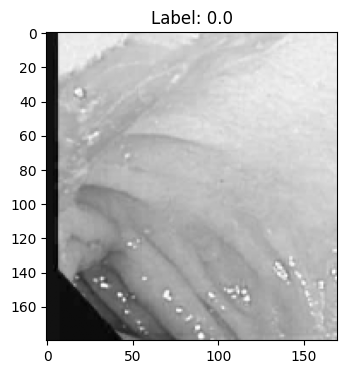

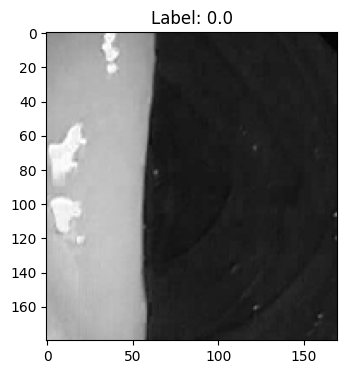

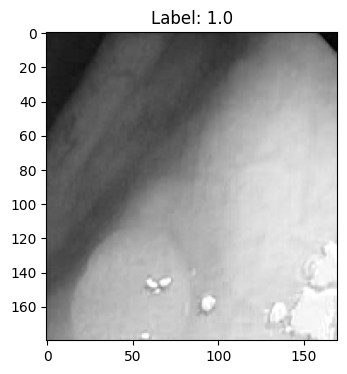

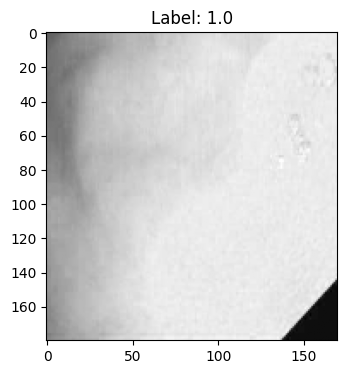

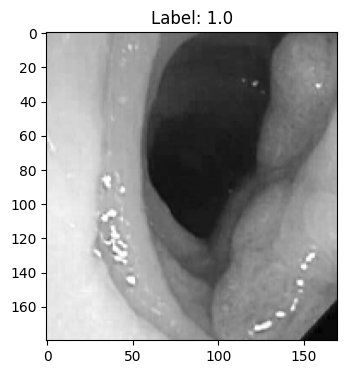

In [ ]:
sample_data = [train_dicts[i] for i in random_idx]
sample_data = load(sample_data)

plot_samples(sample_data)

### 6-2. 資料前處理設定
在此設定資料前處理的超參數。並沒有所謂的“最佳”值。可以透過反覆的嘗試找規律。







In [ ]:
train_transform = Compose(loaders+preprocess+augmentation)
val_transform = Compose(loaders+preprocess)
test_transform = Compose(loaders+preprocess)

train_set = generate_dataset(args, train_dicts, train_transform)
val_set = generate_dataset(args, val_dicts, val_transform)
test_set = generate_dataset(args, test_dicts, test_transform)

data_chgnd=False

Loading dataset: 100%|██████████| 25/25 [00:03<00:00,  6.45it/s]


In [ ]:
update(environ_update=False, data_update=True, training_update=False)

data = train_set[0]

print(data['image'].size())
print(data['image'].max())
print(data['image'].min())

torch.Size([6, 1000, 1000])
metatensor(255.2229)
metatensor(-0.1963)


In [ ]:
update(environ_update=False, data_update=True, training_update=False)
check_dist(train_set)
check_dist(val_set)
check_dist(test_set)

[2026-01-30 04:36:46.328][ INFO](root) - number of positive = 46,
        number of negative = 46,
        number of total data = 92
[2026-01-30 04:36:46.334][ INFO](root) - number of positive = 13,
        number of negative = 12,
        number of total data = 25
[2026-01-30 04:36:46.335][ INFO](root) - number of positive = 12,
        number of negative = 13,
        number of total data = 25


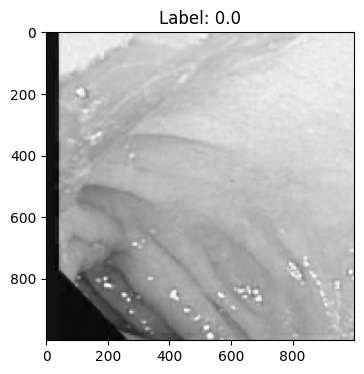

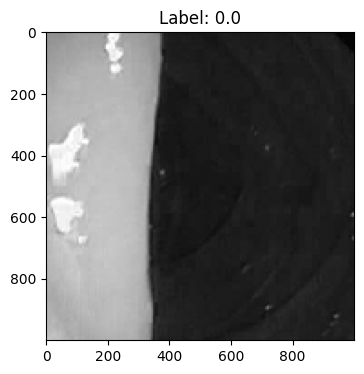

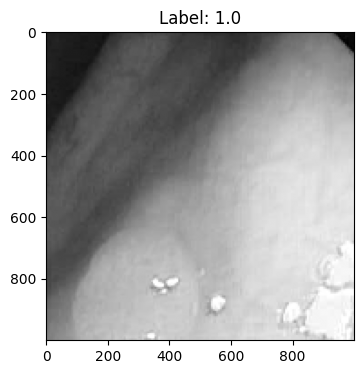

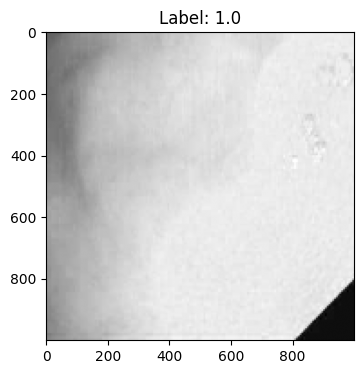

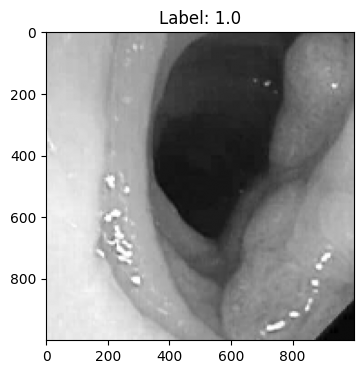

In [ ]:
update(environ_update=False, data_update=True, training_update=False)
sample_data = [train_set[i] for i in random_idx]
plot_samples(sample_data)

## 7\. 訓練


### 7-1. 下載訓練好的模型權重，建組件

In [ ]:
train_loader = generate_dataloader(args, train_set, shuffle=True)
val_loader = generate_dataloader(args, val_set)
test_loader = generate_dataloader(args, test_set)

In [ ]:
#   ,
#__/ \__
#\     /
#/_   _\
#  \ /
#   '
# Set the model
model = create_timm_model(args)

#timm.list_models()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = generate_optimizer(args, model)

training_chgnd=False

[2026-01-30 04:36:48.282][ INFO](timm.models._builder) - Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[2026-01-30 04:36:49.509][ INFO](timm.models._hub) - [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
[2026-01-30 04:36:49.533][ INFO](timm.models._builder) - Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model i

### 7-2. 訓練模型


In [ ]:
%%time
update(environ_update=False, data_update=False, training_update=True)

record = train(args, model, criterion, optimizer, train_loader, val_loader)

  0%|          | 0/1 [00:00<?, ?it/s]

RuntimeError: Given groups=1, weight of size [64, 3, 7, 7], expected input[1, 6, 1000, 1000] to have 3 channels, but got 6 channels instead

In [ ]:
plot_loss_curves(args, record)

NameError: name 'record' is not defined

## 8\. 檢視成果

In [ ]:
# load the best weight and infer
best_state = torch.load("/content/best_weights.pth", weights_only=True)
model.load_state_dict(best_state)

train_true, train_pred = infer(model, train_loader, True)
val_true, val_pred = infer(model, val_loader, True)
test_true, test_pred = infer(model, test_loader, True)

In [ ]:
grad_cam(model, "/content/Melanoma/HAM10000/ISIC_0033616.jpg", 0)

In [ ]:
plot_roc_and_show_result(args, train_true, train_pred, title='Train')
plot_roc_and_show_result(args, val_true, val_pred, title='Validation')
plot_roc_and_show_result(args, test_true, test_pred, title='Test')